# Ambulance Dispatch System

**Project 7 — Emergency Ambulance Dispatch & Routing**

This notebook demonstrates the full simulation pipeline:
- City graph loaded from dummy data
- Poisson-process emergency generation
- Greedy ambulance assignment (baseline)
- Objective function evaluation

Team B2 will plug in Real-Time A*, Greedy vs A* assignment, and Hill Climbing.

## 1. Setup — imports and paths

In [ ]:
import sys
import os

# Add src/ to path so we can import our modules
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

DATA_DIR = os.path.join(os.getcwd(), 'Data')

from graph import CityGraph
from emergency_generator import EmergencyGenerator
from objective import compute_avg_response_time, compute_coverage, objective, print_metrics
from simulation import Simulation

print('All modules loaded successfully.')

All modules loaded successfully.


## 2. Load and inspect the city graph

In [ ]:
graph = CityGraph(
    nodes_path=os.path.join(DATA_DIR, 'nodes.json'),
    edges_path=os.path.join(DATA_DIR, 'edges.json')
)

graph.summary()

In [ ]:
# Inspect travel times on the same road in normal vs rush-hour traffic
sample_edge = {'length': 1500, 'type': 'highway'}

graph.set_traffic('normal')
t_normal = graph.travel_time(sample_edge)

graph.set_traffic('rush_hour')
t_rush = graph.travel_time(sample_edge)

graph.set_traffic('normal')  # reset

print(f'Highway road (1500m):')
print(f'  Normal traffic  : {t_normal:.1f}s ({t_normal/60:.2f} min)')
print(f'  Rush hour       : {t_rush:.1f}s ({t_rush/60:.2f} min)')
print(f'  Slowdown factor : {t_rush/t_normal:.2f}x')

In [ ]:
# Inspect neighbors of node 0 (Central Square)
print('Neighbors of node 0 (Central Square) — normal traffic:')
for neighbor_id, travel_time in graph.neighbors(0):
    name = graph.nodes[neighbor_id]['name']
    print(f'  → Node {neighbor_id:2d} ({name:<25}) : {travel_time:.1f}s')

## 3. Visualize the city graph

Plot all nodes and edges. Color-coded by node type.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json

with open(os.path.join(DATA_DIR, 'nodes.json')) as f:
    nodes = json.load(f)
with open(os.path.join(DATA_DIR, 'edges.json')) as f:
    edges = json.load(f)

node_map = {n['id']: n for n in nodes}

COLOR_MAP = {'intersection': '#4A90D9', 'hospital': '#E74C3C', 'depot': '#2ECC71'}
EDGE_COLOR = {'highway': '#333333', 'main': '#888888', 'small': '#CCCCCC'}
EDGE_WIDTH = {'highway': 2.0, 'main': 1.2, 'small': 0.6}

fig, ax = plt.subplots(figsize=(10, 8))

# Draw edges (draw each edge only once: from < to)
drawn = set()
for e in edges:
    key = (min(e['from'], e['to']), max(e['from'], e['to']))
    if key in drawn:
        continue
    drawn.add(key)
    a, b = node_map[e['from']], node_map[e['to']]
    ax.plot([a['lon'], b['lon']], [a['lat'], b['lat']],
            color=EDGE_COLOR[e['type']], linewidth=EDGE_WIDTH[e['type']], zorder=1)

# Draw nodes
for n in nodes:
    color = COLOR_MAP[n['type']]
    size = 120 if n['type'] == 'intersection' else 250
    ax.scatter(n['lon'], n['lat'], c=color, s=size, zorder=3, edgecolors='white', linewidths=0.5)
    if n['type'] != 'intersection':
        ax.annotate(n['name'], (n['lon'], n['lat']),
                    textcoords='offset points', xytext=(6, 4), fontsize=7, color='#333333')
    else:
        ax.annotate(str(n['id']), (n['lon'], n['lat']),
                    textcoords='offset points', xytext=(3, 3), fontsize=6, color='#555555')

# Legend
legend_handles = [
    mpatches.Patch(color='#4A90D9', label='Intersection'),
    mpatches.Patch(color='#E74C3C', label='Hospital'),
    mpatches.Patch(color='#2ECC71', label='Depot'),
    plt.Line2D([0],[0], color='#333333', linewidth=2, label='Highway'),
    plt.Line2D([0],[0], color='#888888', linewidth=1.2, label='Main road'),
    plt.Line2D([0],[0], color='#CCCCCC', linewidth=0.6, label='Small road'),
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=8)

ax.set_title('Dummy City Graph — Ambulance Dispatch System', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('city_graph.png', dpi=150)
plt.show()
print('Map saved to city_graph.png')

## 4. Emergency generator — Poisson arrivals

In [ ]:
import matplotlib.pyplot as plt

intersection_ids = graph.get_nodes_by_type('intersection')
gen = EmergencyGenerator(intersection_ids, rate_per_hour=6, seed=42)

# Simulate 1 hour of emergency arrivals
arrivals = []
t = 0
while t < 3600:
    t += gen.time_until_next()
    if t < 3600:
        arrivals.append(t)

print(f'Emergencies in 1 simulated hour : {len(arrivals)}')
print(f'Expected (lambda=6/hr)          : ~6')
print(f'Average inter-arrival time      : {3600/len(arrivals):.1f}s')

# Plot the arrival timeline
fig, ax = plt.subplots(figsize=(10, 2))
ax.vlines(arrivals, 0, 1, color='#E74C3C', linewidth=2)
ax.set_xlim(0, 3600)
ax.set_xlabel('Simulation time (seconds)')
ax.set_title('Emergency arrivals — Poisson process (λ = 6/hr)')
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 5. Run the full simulation (1 hour, normal traffic)

In [2]:
sim = Simulation(data_dir=DATA_DIR, time_step=30)
sim.run(duration_seconds=3600)

Simulation initialized.
CityGraph loaded:
  Nodes       : 25
  Edges       : 66
  Hospitals   : 3
  Depots      : 2
  Traffic mode: normal

Starting simulation: 3600s (1.0 hours)
Traffic mode: normal


[t=287.5s] *** EMERGENCY 0 at node 12 ***
  [ASSIGN] Ambulance 2 → Emergency 0 at node 12 (ETA: 200s)
  [ARRIVE] Ambulance 2 reached scene. Response time: 222s. Transporting to hospital node 22.
  [FREE]   Ambulance 2 is now idle at node 22.

[t=935.1s] *** EMERGENCY 1 at node 18 ***
  [ASSIGN] Ambulance 0 → Emergency 1 at node 18 (ETA: 344s)

[t=1130.5s] *** EMERGENCY 2 at node 5 ***
  [ASSIGN] Ambulance 3 → Emergency 2 at node 5 (ETA: 136s)
  [ARRIVE] Ambulance 3 reached scene. Response time: 160s. Transporting to hospital node 21.
  [ARRIVE] Ambulance 0 reached scene. Response time: 385s. Transporting to hospital node 21.

[t=1376.7s] *** EMERGENCY 3 at node 11 ***
  [ASSIGN] Ambulance 1 → Emergency 3 at node 11 (ETA: 265s)
  [FREE]   Ambulance 3 is now idle at node 21.
  [FREE]   Amb

## 6. Run the simulation with rush-hour traffic (comparison)

In [ ]:
sim.reset()
sim.set_rush_hour()
sim.run(duration_seconds=3600)

## 7. Response Time Histogram

In [ ]:
import matplotlib.pyplot as plt

resolved = [e for e in sim.emergencies if e['arrival_time'] is not None]
response_times_min = [(e['arrival_time'] - e['call_time']) / 60 for e in resolved]

if response_times_min:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(response_times_min, bins=10, color='#4A90D9', edgecolor='white')
    ax.axvline(sum(response_times_min)/len(response_times_min),
               color='#E74C3C', linestyle='--', label=f'Mean: {sum(response_times_min)/len(response_times_min):.1f} min')
    ax.set_xlabel('Response time (minutes)')
    ax.set_ylabel('Number of emergencies')
    ax.set_title('Response Time Histogram')
    ax.legend()
    plt.tight_layout()
    plt.savefig('response_time_histogram.png', dpi=150)
    plt.show()
else:
    print('No resolved emergencies yet — run the simulation first.')

## 8. Objective function demo

Shows how the scoring functions work — Team B2 (Hill Climbing) will call these.

In [ ]:
import json

with open(os.path.join(DATA_DIR, 'ambulances.json')) as f:
    ambulances = json.load(f)

rt = compute_avg_response_time(sim.emergencies)
cov = compute_coverage(ambulances, graph)
obj = objective(sim.emergencies, ambulances, graph)

print(f'Average response time : {rt:.1f} seconds')
print(f'Coverage score        : {cov:.0f} (higher = better spread)')
print(f'Combined objective    : {obj:.2f} (lower = better overall)')

## 9. Ready for Team B2

The stubs `src/a_star.py`, `src/assignment.py`, and `src/hill_climbing.py` are ready.

To plug in A*-based dispatch, replace the `simple_assign()` call in `simulation.py` with `astar_assign(graph, ambulances, emergency)` from `assignment.py`.

All interfaces are fixed — no changes needed to `graph.py`, `objective.py`, or the data files.

## 10. Lifecycle Validation (arrival_time vs hospital_time)

Run this after a simulation run to confirm emergency state transitions are consistent.

In [3]:
# Validation summary for emergency lifecycle fields.
# Expected: hospital_time is never set before arrival_time.

total = len(sim.emergencies)
arrived = sum(1 for e in sim.emergencies if e["arrival_time"] is not None)
hospital_done = sum(1 for e in sim.emergencies if e["hospital_time"] is not None)
assigned = sum(1 for e in sim.emergencies if e["status"] == "assigned")
waiting = sum(1 for e in sim.emergencies if e["status"] == "waiting")
resolved = sum(1 for e in sim.emergencies if e["status"] == "resolved")

bad_order = sum(
    1
    for e in sim.emergencies
    if e["hospital_time"] is not None
    and e["arrival_time"] is not None
    and e["hospital_time"] <= e["arrival_time"]
)
missing_arrival = sum(
    1
    for e in sim.emergencies
    if e["hospital_time"] is not None and e["arrival_time"] is None
)

print("Total emergencies     :", total)
print("arrival_time set      :", arrived)
print("hospital_time set     :", hospital_done)
print("status=assigned       :", assigned)
print("status=waiting        :", waiting)
print("status=resolved       :", resolved)

print("\nIntegrity checks")
print("hospital_time <= arrival_time count:", bad_order)
print("hospital_time without arrival_time count:", missing_arrival)

if bad_order == 0 and missing_arrival == 0:
    print("\nPASS: Lifecycle timing fields are consistent.")
else:
    print("\nWARNING: Found lifecycle inconsistencies. Inspect simulation transitions.")

Total emergencies     : 7
arrival_time set      : 6
hospital_time set     : 6
status=assigned       : 1
status=waiting        : 0
status=resolved       : 6

Integrity checks
hospital_time <= arrival_time count: 0
hospital_time without arrival_time count: 0

PASS: Lifecycle timing fields are consistent.


## 11. Comparative Evaluation (Normal vs Rush Hour)

This section stores each run separately and compares response-time distributions side by side.

Simulation initialized.
CityGraph loaded:
  Nodes       : 25
  Edges       : 66
  Hospitals   : 3
  Depots      : 2
  Traffic mode: normal
[t=0s] Traffic mode: NORMAL

Starting simulation: 3600s (1.0 hours)
Traffic mode: normal


[t=948.1s] *** EMERGENCY 0 at node 6 ***
  [ASSIGN] Ambulance 0 → Emergency 0 at node 6 (ETA: 153s)
  [ARRIVE] Ambulance 0 reached scene. Response time: 192s. Transporting to hospital node 21.

[t=1188.4s] *** EMERGENCY 1 at node 4 ***
  [ASSIGN] Ambulance 1 → Emergency 1 at node 4 (ETA: 191s)
  [FREE]   Ambulance 0 is now idle at node 21.
  [ARRIVE] Ambulance 1 reached scene. Response time: 222s. Transporting to hospital node 20.
  [FREE]   Ambulance 1 is now idle at node 20.

[t=1698.5s] *** EMERGENCY 2 at node 0 ***
  [ASSIGN] Ambulance 4 → Emergency 2 at node 0 (ETA: 65s)
  [ARRIVE] Ambulance 4 reached scene. Response time: 101s. Transporting to hospital node 21.
  [FREE]   Ambulance 4 is now idle at node 21.

[t=2587.8s] *** EMERGENCY 3 at node 4 ***
  [A

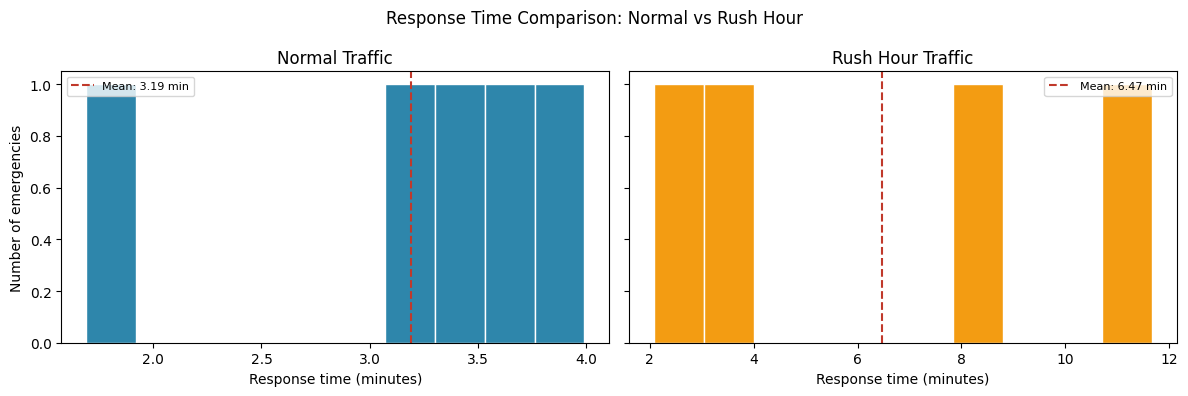

Resolved (normal): 5 | Mean: 3.19
Resolved (rush)  : 4 | Mean: 6.47


In [2]:
import copy
import matplotlib.pyplot as plt

# Run normal-traffic scenario and store results independently.
sim = Simulation(data_dir=DATA_DIR, time_step=30)
sim.set_normal_traffic()
sim.run(duration_seconds=3600)
emergencies_normal = copy.deepcopy(sim.emergencies)

# Run rush-hour scenario and store results independently.
sim.reset()
sim.set_rush_hour()
sim.run(duration_seconds=3600)
emergencies_rush = copy.deepcopy(sim.emergencies)

rt_normal = [
    (e['arrival_time'] - e['call_time']) / 60
    for e in emergencies_normal
    if e['arrival_time'] is not None
]
rt_rush = [
    (e['arrival_time'] - e['call_time']) / 60
    for e in emergencies_rush
    if e['arrival_time'] is not None
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

if rt_normal:
    axes[0].hist(rt_normal, bins=10, color='#2E86AB', edgecolor='white')
    axes[0].axvline(
        sum(rt_normal) / len(rt_normal),
        color='#C0392B',
        linestyle='--',
        label=f"Mean: {sum(rt_normal) / len(rt_normal):.2f} min"
    )
    axes[0].legend(fontsize=8)
else:
    axes[0].text(0.5, 0.5, 'No resolved emergencies', ha='center', va='center')

if rt_rush:
    axes[1].hist(rt_rush, bins=10, color='#F39C12', edgecolor='white')
    axes[1].axvline(
        sum(rt_rush) / len(rt_rush),
        color='#C0392B',
        linestyle='--',
        label=f"Mean: {sum(rt_rush) / len(rt_rush):.2f} min"
    )
    axes[1].legend(fontsize=8)
else:
    axes[1].text(0.5, 0.5, 'No resolved emergencies', ha='center', va='center')

axes[0].set_title('Normal Traffic')
axes[1].set_title('Rush Hour Traffic')
axes[0].set_ylabel('Number of emergencies')
for ax in axes:
    ax.set_xlabel('Response time (minutes)')

plt.suptitle('Response Time Comparison: Normal vs Rush Hour')
plt.tight_layout()
plt.show()

print('Resolved (normal):', len(rt_normal), '| Mean:', round(sum(rt_normal) / len(rt_normal), 2) if rt_normal else 'N/A')
print('Resolved (rush)  :', len(rt_rush), '| Mean:', round(sum(rt_rush) / len(rt_rush), 2) if rt_rush else 'N/A')